## Random tie-breaking for tree packings

This code accompanies the paper "Greedy matroid base packings with applications to dynamic graph
density". The notebook gives experimental evidence that random tie-breaking in the edge order does not improve the lower-bound asymptotics for greedy tree packing on the multigraph $G_n$ from the paper. Every edge has ideal relative load
$$
\ell_e^* = \frac{n-1}{2n-1}.
$$
We measure the packing error in terms of $\max_e |L_e^k-k\ell_e^*|$, where $k$ is the number of trees packed. Growth proportional to $\sqrt{k}$ implies, after division by $k$, that the $\ell_\infty$-error is of order $1/\sqrt{k}$.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [2]:
n = 500
num_trees = 5000
seeds = (42, 67, 1729, 47_176_870)
display_seed = 67

### The graph construction

The vertices are $1,\ldots,n$. There is a path on the vertices $2,\ldots,n$, vertex $1$ is adjacent to all other vertices, and edges $(1,2)$ and $(1,n)$ are doubled.

In [3]:
def fan_multigraph(n):
    """Return the multigraph G_n from the paper."""
    if n < 3:
        raise ValueError("n must be at least 3")

    graph = nx.MultiGraph()
    graph.add_nodes_from(range(1, n + 1))

    graph.add_edge(1, 2)
    graph.add_edge(1, 2)
    for vertex in range(3, n + 1):
        graph.add_edge(vertex - 1, vertex)
        graph.add_edge(1, vertex)
    graph.add_edge(1, n)

    return graph

Draw an example:

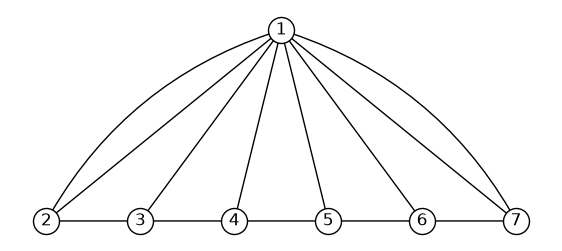

In [4]:
example_n = 7
example = fan_multigraph(example_n)
pos = {
    1: ((example_n - 2) / 2, 2),
    **{v: (v - 2, 0) for v in range(2, example_n + 1)},
}
fig, ax = plt.subplots(figsize=(example_n, 3))
nx.draw_networkx_nodes(
    example, pos, node_color='white', edgecolors='black',
    node_size=350, ax=ax,
)
nx.draw_networkx_labels(example, pos, ax=ax)
for u, v, key in example.edges:
    radius = 0
    if v == 2 and key == 0:
        radius = 0.2
    elif v == example_n and key == 1:
        radius = -0.2
    nx.draw_networkx_edges(
        example, pos, edgelist=[(u, v, key)],
        connectionstyle=f'arc3,rad={radius}', arrows=True,
        arrowstyle='-', ax=ax,
    )
ax.set_axis_off()
fig.savefig('example_graph.pdf', bbox_inches='tight')

### Randomized greedy tree packing

At every iteration, we find a minimum spanning tree with respect to the edge weights being the integral edge loads perturbed by fresh independent noise from $[0,0.1]$. Then equal-load edges appear in a uniformly random order, but the order of edges with different loads is unchanged.

In [5]:
def get_edge_loads(
    graph,
    num_trees,
    with_random_tiebreaking=True,
    seed=None,
):
    """Return the integral edge-load vector after each packed tree."""
    rng = np.random.default_rng(seed)
    edges = list(graph.edges)
    weights = dict.fromkeys(edges, 0)
    load_vectors = np.zeros(
        (num_trees + 1, len(edges)), dtype=np.int32,
    )

    for step in range(num_trees):
        if with_random_tiebreaking:
            values = {
                edge: weight + rng.uniform(0, 0.1)
                for edge, weight in weights.items()
            }
        else:
            values = weights
        nx.set_edge_attributes(graph, values=values, name='weight')

        mst = nx.minimum_spanning_tree(
            graph, algorithm='kruskal', weight='weight',
        )
        for edge in mst.edges:
            weights[edge] += 1
        load_vectors[step + 1] = tuple(weights.values())

    return load_vectors

Run the experiments:

In [6]:
graph = fan_multigraph(n)
assert graph.number_of_edges() == 2 * n - 1

ideal_load = (n - 1) / (2 * n - 1)
tree_counts = np.arange(1, num_trees + 1)
load_errors_by_seed = {}
display_load_vectors = None

for seed in seeds:
    load_vectors = get_edge_loads(graph, num_trees, seed=seed)
    discrepancies = np.abs(
        load_vectors[1:] - ideal_load * tree_counts[:, None]
    )
    load_errors_by_seed[seed] = discrepancies.max(axis=1)
    if seed == display_seed:
        display_load_vectors = load_vectors

assert display_load_vectors is not None

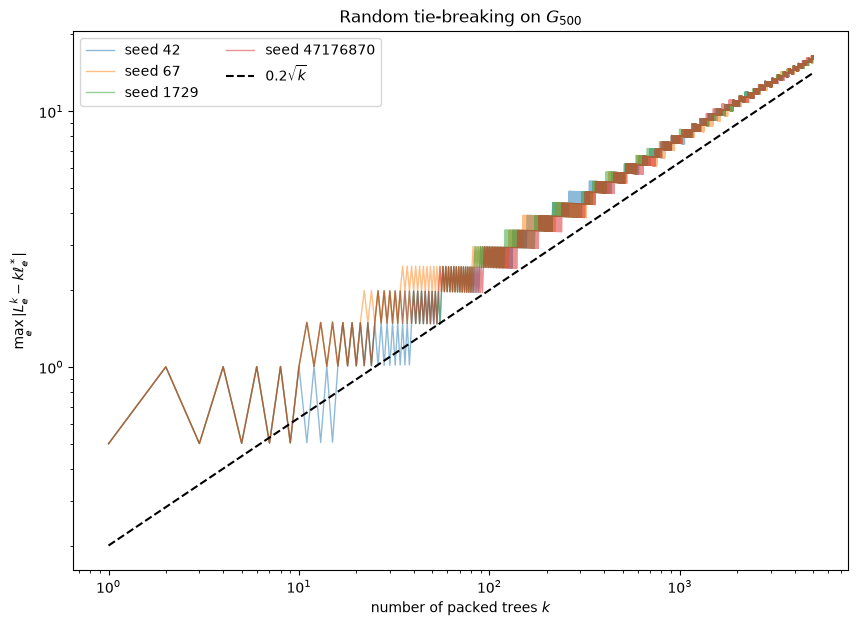

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
for seed in seeds:
    ax.plot(
        tree_counts, load_errors_by_seed[seed],
        linewidth=1, alpha=0.5, label=f'seed {seed}',
    )
ax.plot(
    tree_counts, 0.2 * np.sqrt(tree_counts), 'k--',
    label=r'$0.2\sqrt{k}$',
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('number of packed trees $k$')
ax.set_ylabel(r'$\max_e|L_e^k-k\ell_e^*|$')
ax.set_title(f'Random tie-breaking on $G_{{{n}}}$')
ax.legend(ncol=2)
fig.savefig('load_error_plot.pdf', bbox_inches='tight')

Visualize the final load state -- the edges close to either end of the graph are underpacked:

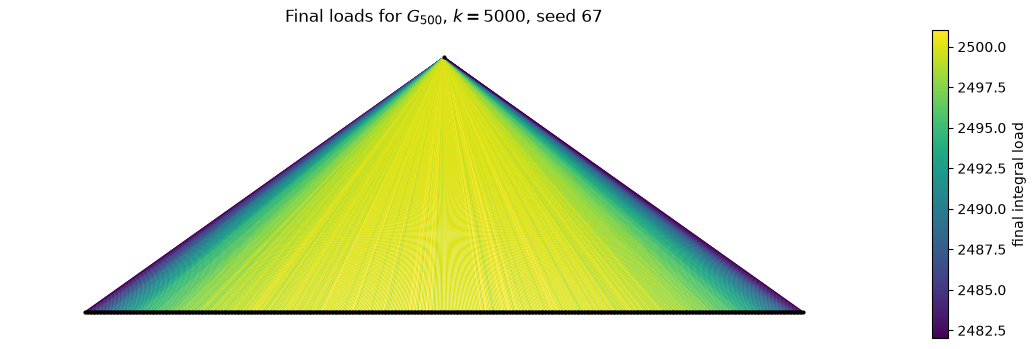

In [8]:
pos = {
    1: ((n - 2) / 2, n / 5),
    **{v: (v - 2, 0) for v in range(2, n + 1)},
}
final_loads = display_load_vectors[-1]
normalization = plt.Normalize(final_loads.min(), final_loads.max())

fig, ax = plt.subplots(figsize=(14, 4))
nx.draw_networkx_nodes(
    graph, pos, node_color='black', node_size=4, ax=ax,
)
nx.draw_networkx_edges(
    graph, pos, edgelist=list(graph.edges),
    edge_color=final_loads, edge_cmap=plt.cm.viridis,
    edge_vmin=final_loads.min(), edge_vmax=final_loads.max(),
    width=0.8, node_size=4, ax=ax,
)
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=normalization, cmap=plt.cm.viridis,
    ),
    ax=ax, label='final integral load',
)
ax.set_title(
    f'Final loads for $G_{{{n}}}$, $k={num_trees}$, '
    f'seed {display_seed}',
)
ax.set_axis_off()
fig.savefig('final_loads_graph.pdf', bbox_inches='tight')

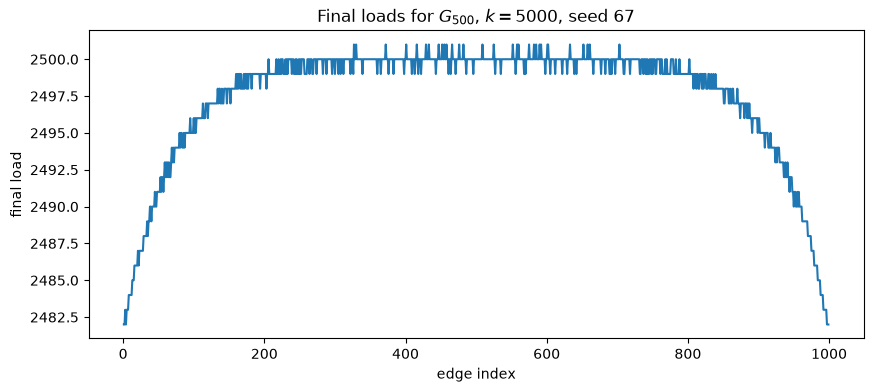

In [9]:
paper_edge_order = [(1, 2, 0), (1, 2, 1)]
for vertex in range(3, n + 1):
    paper_edge_order.extend([
        (vertex - 1, vertex, 0), (1, vertex, 0),
    ])
paper_edge_order.append((1, n, 1))

edge_index = {
    edge: index for index, edge in enumerate(graph.edges)
}
ordered_loads = [
    final_loads[edge_index[edge]] for edge in paper_edge_order
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    np.arange(1, len(paper_edge_order) + 1), ordered_loads,
)
ax.set_xlabel("edge index")
ax.set_ylabel('final load')
ax.set_title(
    f'Final loads for $G_{{{n}}}$, $k={num_trees}$, '
    f'seed {display_seed}',
)
fig.savefig('load_vs_index_plot.pdf', bbox_inches='tight')

### Conclusion

Across several random seeds, the values $\max_e |L_e^k-k\ell_e^*|$ grow proportional to $\sqrt{k}$. Thus, the relative-load error is of order $1/\sqrt{k}$. This is experimental evidence that random tie-breaking on the edges might not help for the $\ell_\infty$-error in tree packings. However, this is just empirical evidence and not a proof. Also, it does not rule out the possibility that with a different kind of randomization, one could obtain a more optimistic bound on the error.